## Data Exploration

Esplorazione diretta di `data/clinical_connectome/derivatives`: quanti dataset, quali tipologie di dato per ciascuno, quanti file per soggetto, e verifica di consistenza (file attesi, duplicati, copertura incrociata).

In [79]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from collections import defaultdict

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Path dinamici relativi alla posizione del progetto
project_root = '/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs'
DERIV_ROOT = Path(project_root) / "data" / "clinical_connectome" / "derivatives"


**Dataset** = cartella a profondità 2 sotto `derivatives` (site/cohort, es. `UNIPD/WashU`).

**Tipologia di dato** = sua sottocartella di primo livello (`manual_masks`, `sdc`, `features`).

In [80]:
def discover_datasets(deriv_root: Path) -> dict[str, Path]:
    return {
        f"{site.name}/{cohort.name}": cohort
        for site in sorted(deriv_root.iterdir()) if site.is_dir()
        for cohort in sorted(site.iterdir()) if cohort.is_dir()
    }

def discover_data_types(dataset_path: Path) -> dict[str, Path]:
    return {p.name: p for p in sorted(dataset_path.iterdir()) if p.is_dir()}

def discover_subjects(type_path: Path) -> list[str]:
    return sorted(p.name for p in type_path.iterdir() if p.is_dir())

def file_types_for_subject(subject_dir: Path, subject_id: str) -> set[str]:
    """File presenti per un soggetto, generalizzati (subject_id -> placeholder)."""
    return {
        str(f.relative_to(subject_dir)).replace(subject_id, "{subject_id}")
        for f in subject_dir.rglob("*") if f.is_file()
    }


### Quanti dataset ci sono

In [81]:
datasets = discover_datasets(DERIV_ROOT)

print(f"Trovati {len(datasets)} dataset in '{DERIV_ROOT}':\n")
for name in datasets:
    print(f" - {name}")


Trovati 6 dataset in '/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/data/clinical_connectome/derivatives':

 - UCL-UK/UCLStrokeData
 - UKE/WAKEUP_acute
 - UKLFR/stroke_UKLFR
 - UNIPD/PASPORT
 - UNIPD/PSP
 - UNIPD/WashU


### Quante tipologie di dati ci sono per dataset

Per ogni dataset: quali tipologie esistono, riassunte in una tabella dataset × tipologia (presente/assente).

In [82]:
presence_by_dataset = {}  # dataset -> DataFrame(subject_id x tipologia -> bool)

for name, dataset_path in datasets.items():
    types = discover_data_types(dataset_path)
    print(f"{name}: {len(types)} tipologie -> {sorted(types)}")

    subjects_by_type = {t: set(discover_subjects(p)) for t, p in types.items()}
    all_subjects = sorted(set().union(*subjects_by_type.values())) if subjects_by_type else []

    presence_by_dataset[name] = pd.DataFrame(
        {t: [s in subjects_by_type[t] for s in all_subjects] for t in sorted(types)},
        index=all_subjects,
    )


UCL-UK/UCLStrokeData: 1 tipologie -> ['manual_masks']
UKE/WAKEUP_acute: 2 tipologie -> ['manual_masks', 'sdc']
UKLFR/stroke_UKLFR: 2 tipologie -> ['manual_masks', 'sdc']
UNIPD/PASPORT: 2 tipologie -> ['manual_masks', 'sdc']
UNIPD/PSP: 2 tipologie -> ['manual_masks', 'sdc']
UNIPD/WashU: 3 tipologie -> ['features', 'manual_masks', 'sdc']


In [83]:
# tabella dataset × tipologia (True/False)
all_types = sorted({t for presence in presence_by_dataset.values() for t in presence.columns})

dataset_type_availability = pd.DataFrame(
    {t: [t in presence_by_dataset[name].columns for name in datasets] for t in all_types},
    index=list(datasets),
)
display(dataset_type_availability)


,features,manual_masks,sdc
UCL-UK/UCLStrokeData,False,True,False
UKE/WAKEUP_acute,False,True,True
UKLFR/stroke_UKLFR,False,True,True
UNIPD/PASPORT,False,True,True
UNIPD/PSP,False,True,True
UNIPD/WashU,True,True,True


### In ogni tipologia quante tipologie di dato ci sono per un soggetto

Per ogni tipologia, unione dei pattern di file su tutti i soggetti/dataset che la possiedono, poi verifica che ogni soggetto li abbia tutti. Il dettaglio si stampa solo se ci sono eccezioni:

- **assenza strutturale**: il dataset non ha mai avuto quel pattern (es. i `mapstats` solo su UKE)
- **assenza sporadica**: un soggetto a cui manca un pattern che gli altri del suo dataset hanno

In [84]:
file_types_by_type = defaultdict(set)
file_types_by_subject = {}  # (type_name, dataset, subject_id) -> set di pattern

for name, dataset_path in datasets.items():
    for type_name, type_path in discover_data_types(dataset_path).items():
        for subject_id in discover_subjects(type_path):
            patterns = file_types_for_subject(type_path / subject_id, subject_id)
            file_types_by_type[type_name] |= patterns
            file_types_by_subject[(type_name, name, subject_id)] = patterns

for type_name in sorted(file_types_by_type):
    expected = file_types_by_type[type_name]
    print(f"\n=== {type_name}: {len(expected)} tipologie di file ===")

    for name, dataset_path in datasets.items():
        types = discover_data_types(dataset_path)
        if type_name not in types:
            continue
        subjects = discover_subjects(types[type_name])

        # assenze strutturali
        own_union = set().union(*(file_types_by_subject[(type_name, name, s)] for s in subjects)) if subjects else set()
        structurally_absent = expected - own_union

        # assenze sporadiche
        sporadic_missing = {
            s: (expected - file_types_by_subject[(type_name, name, s)]) - structurally_absent
            for s in subjects
        }
        sporadic_missing = {s: m for s, m in sporadic_missing.items() if m}

        if not structurally_absent and not sporadic_missing:
            print(f"✅ {name}: presenti per tutti i {len(subjects)} soggetti")
            continue

        if structurally_absent:
            print(f"ℹ️ {name}: non include {len(structurally_absent)}/{len(expected)} pattern (presenti solo in altri dataset): {sorted(structurally_absent)}")
        if sporadic_missing:
            print(f"⚠️ {name}: {len(sporadic_missing)}/{len(subjects)} soggetti con file mancanti in modo non sistematico")
            for subject_id, missing in list(sporadic_missing.items())[:10]:
                print(f"    - {subject_id}: manca {sorted(missing)}")
            if len(sporadic_missing) > 10:
                print(f"    ... +{len(sporadic_missing) - 10} altri soggetti")



=== features: 16 tipologie di file ===
✅ UNIPD/WashU: presenti per tutti i 10 soggetti

=== manual_masks: 1 tipologie di file ===
✅ UCL-UK/UCLStrokeData: presenti per tutti i 4119 soggetti
✅ UKE/WAKEUP_acute: presenti per tutti i 451 soggetti
✅ UKLFR/stroke_UKLFR: presenti per tutti i 697 soggetti
✅ UNIPD/PASPORT: presenti per tutti i 83 soggetti
✅ UNIPD/PSP: presenti per tutti i 168 soggetti
✅ UNIPD/WashU: presenti per tutti i 202 soggetti

=== sdc: 34 tipologie di file ===
✅ UKE/WAKEUP_acute: presenti per tutti i 451 soggetti
✅ UKLFR/stroke_UKLFR: presenti per tutti i 705 soggetti
✅ UNIPD/PASPORT: presenti per tutti i 83 soggetti
✅ UNIPD/PSP: presenti per tutti i 168 soggetti
✅ UNIPD/WashU: presenti per tutti i 195 soggetti


### Per ogni tipologia, per ogni dataset: quanti soggetti ci sono

Conteggio soggetti per tipologia, in una tabella per dataset (righe = dataset, colonne = tipologia). Controllo duplicati esplicito (i nomi di cartella non possono duplicarsi su un filesystem, ma è verificato comunque).

WashU è corretta e divisa in due righe (`ST`/`HC`): `features` su disco è solo il campione locale ridotto (10 soggetti), la copertura reale (225) viene dal manifest verificato dell'archivio compresso (`features/features_archive_subjects.tsv`) — e i controlli sani (HC) non hanno mai `manual_masks`/`sdc` per costruzione, quindi vanno separati dai pazienti (ST).

In [85]:
rows = []
for name, dataset_path in datasets.items():
    for type_name, type_path in discover_data_types(dataset_path).items():
        subjects = discover_subjects(type_path)
        n_unique = len(set(subjects))
        rows.append({
            "dataset": name,
            "tipologia": type_name,
            "n_soggetti": len(subjects),
            "n_duplicati": len(subjects) - n_unique,
        })

# WashU: "features" su disco è solo il campione locale ridotto (10 soggetti) - la
# copertura reale (225, da features/features_archive_subjects.tsv) sostituisce le
# righe grezze, separata in ST/ HC (i controlli sani non hanno mai manual_masks/sdc).
washu_features_manifest = pd.read_csv(datasets["UNIPD/WashU"] / "features" / "features_archive_subjects.tsv", sep="\t")
washu_participants = pd.read_csv(Path(project_root) / "data" / "clinical_connectome" / "metadata_tsv" / "participants_WashU.tsv", sep="\t")
washu_disease_by_subject = washu_participants.set_index("participant_id")["disease_id"]

washu_types = discover_data_types(datasets["UNIPD/WashU"])
washu_subjects_by_type = {
    "manual_masks": set(discover_subjects(washu_types["manual_masks"])),
    "sdc": set(discover_subjects(washu_types["sdc"])),
    "features": set(washu_features_manifest["subject_id"]),
}

rows = [r for r in rows if r["dataset"] != "UNIPD/WashU"]
for group in ["ST", "HC"]:
    group_subjects = set(washu_disease_by_subject[washu_disease_by_subject == group].index)
    for type_name, subjects in washu_subjects_by_type.items():
        rows.append({
            "dataset": f"UNIPD/WashU ({group})",
            "tipologia": type_name,
            "n_soggetti": len(subjects & group_subjects),
            "n_duplicati": 0,
        })

df_counts = pd.DataFrame(rows)

# tabella per dataset (righe = dataset, colonne = tipologia, valori = n_soggetti)
df_counts_wide = df_counts.pivot(index="dataset", columns="tipologia", values="n_soggetti").astype("Int64")
row_order = [d for d in datasets if d != "UNIPD/WashU"] + ["UNIPD/WashU (ST)", "UNIPD/WashU (HC)"]
display(df_counts_wide.reindex(row_order))

dup_rows = df_counts[df_counts["n_duplicati"] > 0]
if dup_rows.empty:
    print("Nessun soggetto duplicato in nessuna tipologia.")
else:
    print(f"⚠️ Trovati {dup_rows['n_duplicati'].sum()} soggetti duplicati totali:")
    display(dup_rows[["dataset", "tipologia", "n_duplicati"]])


tipologia,features,manual_masks,sdc
dataset,,,
UCL-UK/UCLStrokeData,<NA>,4119,<NA>
UKE/WAKEUP_acute,<NA>,451,451
UKLFR/stroke_UKLFR,<NA>,697,705
UNIPD/PASPORT,<NA>,83,83
UNIPD/PSP,<NA>,168,168
UNIPD/WashU (ST),169,202,195
UNIPD/WashU (HC),56,0,0


Nessun soggetto duplicato in nessuna tipologia.


#### Correzione soggetti per WashU

`features` su disco per WashU è solo il campione locale ridotto (10 soggetti) — la copertura reale (225) viene dal manifest verificato dell'archivio compresso (`features/features_archive_subjects.tsv`, vedi `README_ARCHIVE.md` nella stessa cartella). WashU inoltre mescola pazienti (ST) e controlli sani (HC, che per costruzione non hanno mai `manual_masks`/`sdc` — nessuna lesione da segnare): li separiamo in due dataset così i confronti sotto restano sensati.

In [86]:
washu_features_manifest = pd.read_csv(datasets["UNIPD/WashU"] / "features" / "features_archive_subjects.tsv", sep="\t")
washu_real_features_subjects = set(washu_features_manifest["subject_id"])

washu_participants = pd.read_csv(Path(project_root) / "data" / "clinical_connectome" / "metadata_tsv" / "participants_WashU.tsv", sep="\t")
washu_disease_by_subject = washu_participants.set_index("participant_id")["disease_id"]

washu_types = discover_data_types(datasets["UNIPD/WashU"])
manual_masks_subjects = set(discover_subjects(washu_types["manual_masks"]))
sdc_subjects = set(discover_subjects(washu_types["sdc"]))

all_washu_subjects = sorted(set(presence_by_dataset["UNIPD/WashU"].index) | washu_real_features_subjects)
washu_corrected = pd.DataFrame({
    "manual_masks": [s in manual_masks_subjects for s in all_washu_subjects],
    "sdc": [s in sdc_subjects for s in all_washu_subjects],
    "features": [s in washu_real_features_subjects for s in all_washu_subjects],
}, index=all_washu_subjects)

washu_groups = washu_disease_by_subject.reindex(washu_corrected.index)
if washu_groups.isna().any():
    raise ValueError(f"disease_id non trovato per: {washu_groups[washu_groups.isna()].index.tolist()}")

del presence_by_dataset["UNIPD/WashU"]
presence_by_dataset["UNIPD/WashU (ST)"] = washu_corrected[washu_groups == "ST"]
presence_by_dataset["UNIPD/WashU (HC)"] = washu_corrected[washu_groups == "HC"]

for name in ["UNIPD/WashU (ST)", "UNIPD/WashU (HC)"]:
    print(f"{name}: {len(presence_by_dataset[name])} soggetti")
    print(presence_by_dataset[name].sum())
    print()


UNIPD/WashU (ST): 202 soggetti
manual_masks    202
sdc             195
features        169
dtype: int64

UNIPD/WashU (HC): 56 soggetti
manual_masks     0
sdc              0
features        56
dtype: int64



### Confronto a coppie tra due tipologie

Scegli due tipologie (`MOD_A`, `MOD_B`): per ogni dataset che le ha entrambe, elenca i soggetti presenti in una ma non nell'altra, e viceversa — mostrati solo i dataset con almeno un'eccezione.

In [87]:
MOD_A = "manual_masks"
MOD_B = "sdc"

for name, presence in presence_by_dataset.items():
    if MOD_A not in presence.columns or MOD_B not in presence.columns:
        continue

    only_a = presence.index[presence[MOD_A] & ~presence[MOD_B]]
    only_b = presence.index[~presence[MOD_A] & presence[MOD_B]]
    if only_a.empty and only_b.empty:
        continue

    print(f"\n=== {name} ===")
    if not only_a.empty:
        print(f"In '{MOD_A}' ma non in '{MOD_B}' ({len(only_a)}): {list(only_a)}")
    if not only_b.empty:
        print(f"In '{MOD_B}' ma non in '{MOD_A}' ({len(only_b)}): {list(only_b)}")



=== UKLFR/stroke_UKLFR ===
In 'manual_masks' ma non in 'sdc' (24): ['sub-STUKLFR0047', 'sub-STUKLFR0062', 'sub-STUKLFR0069', 'sub-STUKLFR0079', 'sub-STUKLFR0085', 'sub-STUKLFR0141', 'sub-STUKLFR0145', 'sub-STUKLFR0162', 'sub-STUKLFR0266', 'sub-STUKLFR0291', 'sub-STUKLFR0352', 'sub-STUKLFR0353', 'sub-STUKLFR0405', 'sub-STUKLFR0410', 'sub-STUKLFR0429', 'sub-STUKLFR0454', 'sub-STUKLFR0483', 'sub-STUKLFR0510', 'sub-STUKLFR0602', 'sub-STUKLFR0633', 'sub-STUKLFR0660', 'sub-STUKLFR0692', 'sub-STUKLFR0699', 'sub-STUKLFR0732']
In 'sdc' ma non in 'manual_masks' (32): ['sub-STUKLFR0005', 'sub-STUKLFR0035', 'sub-STUKLFR0097', 'sub-STUKLFR0132', 'sub-STUKLFR0142', 'sub-STUKLFR0151', 'sub-STUKLFR0155', 'sub-STUKLFR0166', 'sub-STUKLFR0208', 'sub-STUKLFR0236', 'sub-STUKLFR0238', 'sub-STUKLFR0250', 'sub-STUKLFR0264', 'sub-STUKLFR0275', 'sub-STUKLFR0279', 'sub-STUKLFR0336', 'sub-STUKLFR0393', 'sub-STUKLFR0407', 'sub-STUKLFR0427', 'sub-STUKLFR0434', 'sub-STUKLFR0436', 'sub-STUKLFR0439', 'sub-STUKLFR0441

## Report tsv (Metadata)

Analizza `data/clinical_connectome/metadata_tsv/participants_*.tsv` — un file per dataset, dati clinici/demografici grezzi (non filtrati). Ogni sezione confronta tutti i dataset fianco a fianco, un subplot per dataset.

### Caricamento

In [88]:
METADATA_TSV_DIR = Path(project_root) / "data" / "clinical_connectome" / "metadata_tsv"

TSV_FILES = sorted(METADATA_TSV_DIR.glob("participants_*.tsv"))
PREFIX = "participants_"
datasets_tsv = {f.stem[len(PREFIX):]: pd.read_csv(f, sep="\t") for f in TSV_FILES}

print(f"{len(datasets_tsv)} dataset caricati: {list(datasets_tsv.keys())}")


6 dataset caricati: ['PASPORT', 'PSP', 'UCL', 'UKE', 'UKLFR', 'WashU']


### Columns

In [89]:
all_columns = set()
for df in datasets_tsv.values():
    all_columns |= set(df.columns)

print(f"{len(all_columns)} colonne distinte in totale su {len(datasets_tsv)} dataset\n")
for name, df in datasets_tsv.items():
    print(f"{name}: {len(df.columns)} colonne")


160 colonne distinte in totale su 6 dataset

PASPORT: 16 colonne
PSP: 50 colonne
UCL: 6 colonne
UKE: 84 colonne
UKLFR: 55 colonne
WashU: 38 colonne


Confronto tra i dataset: colonne comuni a tutti, e una tabella colonna × dataset (True/False) per tutte le altre — ordinata da chi è condivisa da più dataset a chi è specifica di uno solo.

In [ ]:
cols_by_dataset = {name: set(df.columns) for name, df in datasets_tsv.items()}
all_columns = set().union(*cols_by_dataset.values())
common_columns = set.intersection(*cols_by_dataset.values())
print(f"Colonne comuni a tutti i {len(datasets_tsv)} dataset ({len(common_columns)}): {sorted(common_columns)}\n")


Colonne comuni a tutti i 6 dataset (6): ['age', 'center_id', 'dataset', 'disease_id', 'participant_id', 'sex']



In [ ]:
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

# Stessa tabella di sopra, esportata in xlsx colorato - più leggibile di True/False
# o della versione colorata solo nell'output della cella.
EXCEL_OUT_PATH = METADATA_TSV_DIR / "columns_by_dataset.xlsx"

with pd.ExcelWriter(EXCEL_OUT_PATH, engine="openpyxl") as writer:
    presence_table.to_excel(writer, sheet_name="colonne")

wb = openpyxl.load_workbook(EXCEL_OUT_PATH)
ws = wb["colonne"]

green = PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid")
gray = PatternFill(start_color="F2F2F2", end_color="F2F2F2", fill_type="solid")

n_rows, n_cols = presence_table.shape
for row in ws.iter_rows(min_row=2, max_row=n_rows + 1, min_col=2, max_col=n_cols + 1):
    for cell in row:
        if cell.value is True:
            cell.fill, cell.value = green, "X"
        else:
            cell.fill, cell.value = gray, None
        cell.alignment = Alignment(horizontal="center")

for cell in ws[1]:
    cell.font = Font(bold=True)

ws.freeze_panes = "B2"
ws.column_dimensions["A"].width = 30
for i in range(2, n_cols + 2):
    ws.column_dimensions[get_column_letter(i)].width = 12

wb.save(EXCEL_OUT_PATH)
print(f"Scritto {EXCEL_OUT_PATH}")


### Utilità di plotting

`dataset_grid(n)` crea una griglia di subplot (righe × colonne, non una singola riga) per confrontare i dataset — usata in tutte le sezioni sotto.

In [91]:
import numpy as np

def dataset_grid(n_items: int, n_cols: int = 3, subplot_size: tuple[float, float] = (4, 4)):
    """Griglia n_rows x n_cols di assi (un subplot per dataset), assi in eccesso nascosti."""
    n_rows = -(-n_items // n_cols)  # ceil division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(subplot_size[0] * n_cols, subplot_size[1] * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes[n_items:]:
        ax.set_visible(False)
    return fig, axes[:n_items]


### Integrità del Dato (Missing Values e Duplicati)


Duplicati su `participant_id` e, per ogni dataset, le colonne con più valori mancanti (max 15 mostrate).

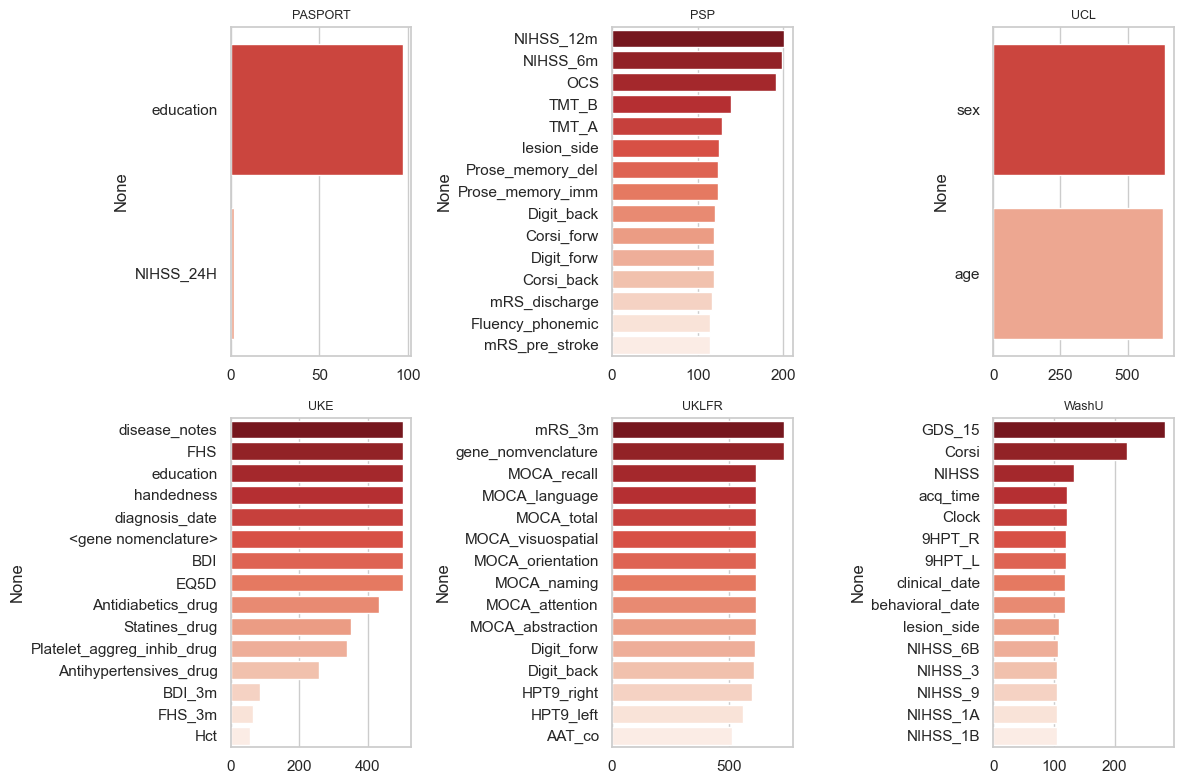

In [92]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(4, 4))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False).head(15)

    if missing.empty:
        ax.text(0.5, 0.5, "nessun missing", ha="center", va="center")
    else:
        sns.barplot(x=missing.values, y=missing.index, hue=missing.index, legend=False, palette="Reds_r", ax=ax)
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show();


### Conteggio Sani vs Malati

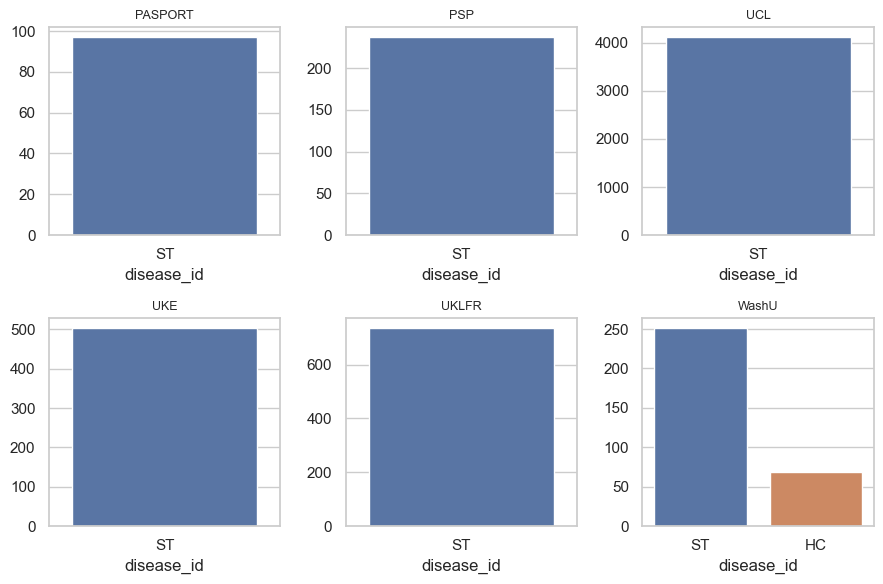

In [93]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(3, 3))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    counts = df["disease_id"].value_counts()
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False, ax=ax)
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show();


### Analisi Demografica


Età (per gruppo, se `disease_id` ha più di un valore) e sesso, ciascuna in una griglia separata.

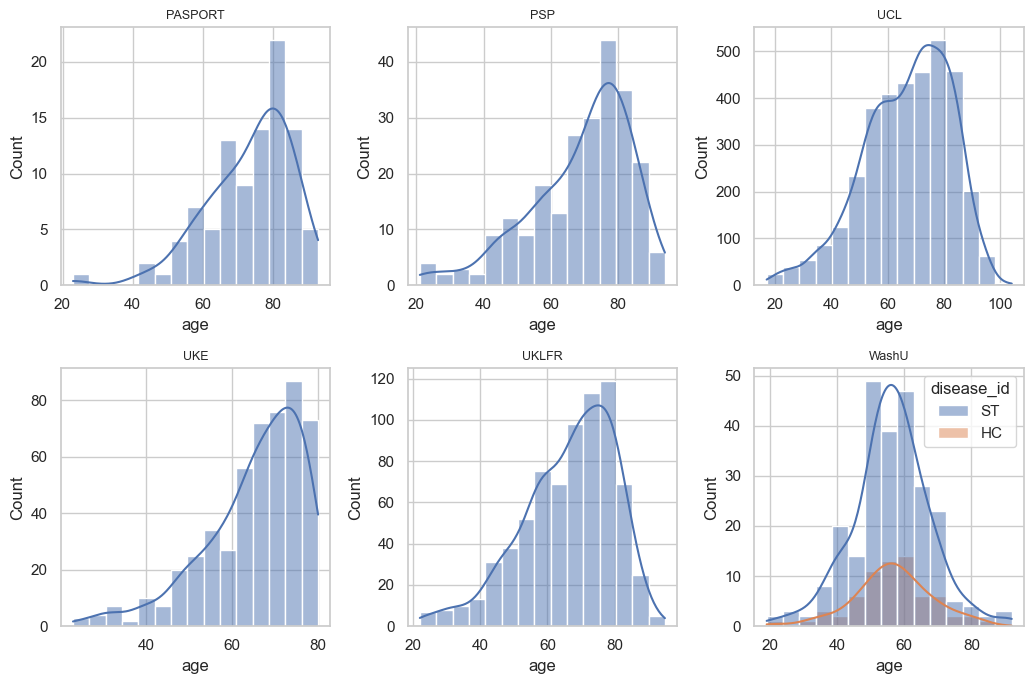

In [94]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(3.5, 3.5))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    hue_col = "disease_id" if df["disease_id"].nunique() > 1 else None
    sns.histplot(data=df, x="age", hue=hue_col, bins=15, kde=True, ax=ax)
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show();


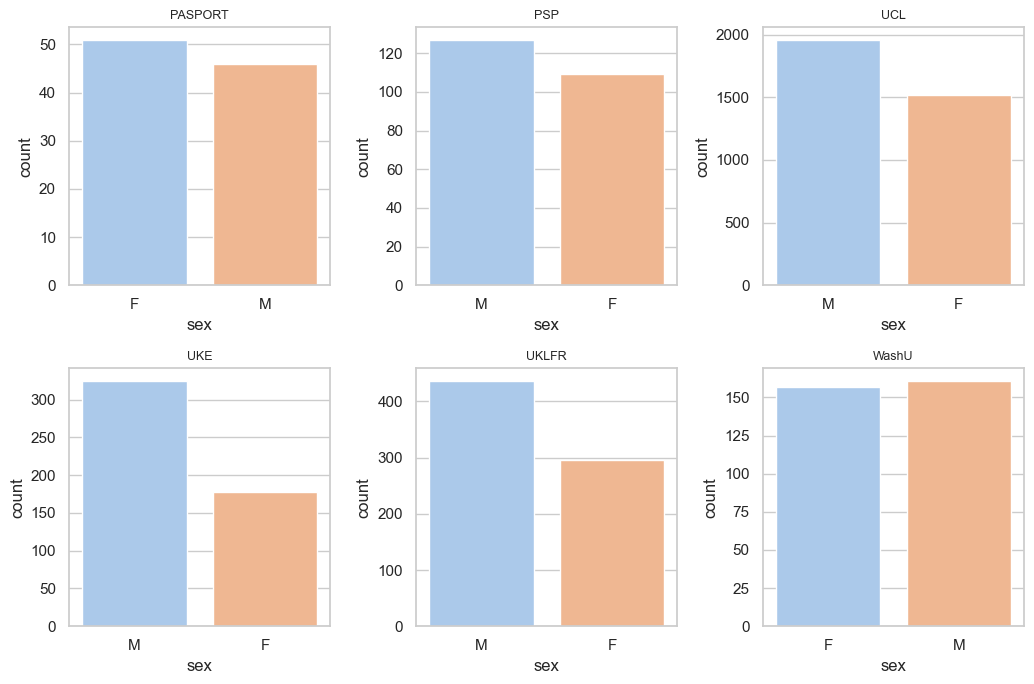

In [95]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(3.5, 3.5))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    if "sex" in df.columns:
        sns.countplot(data=df, x="sex", hue="sex", legend=False, palette="pastel", ax=ax)
    else:
        ax.text(0.5, 0.5, "sex non\ndisponibile", ha="center", va="center")
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show();


### Lateralità della Lesione

Distribuzione delle lesioni per emisfero. `lesion_side` non è disponibile per tutti i dataset (segnalato esplicitamente, non lasciato vuoto in silenzio).

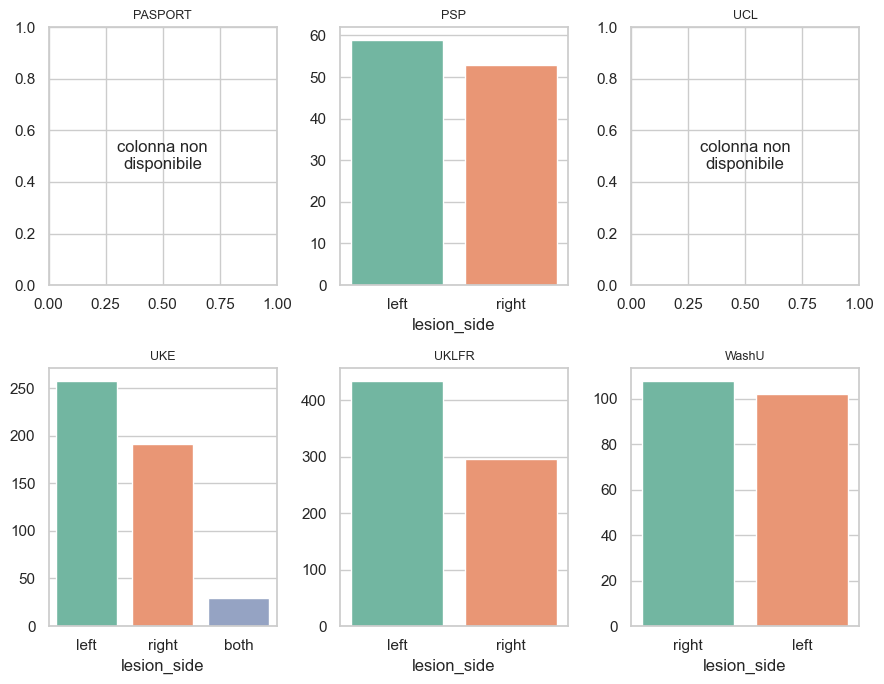

In [96]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(3, 3.5))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    if "lesion_side" not in df.columns:
        ax.text(0.5, 0.5, "colonna non\ndisponibile", ha="center", va="center")
    else:
        counts = df["lesion_side"].value_counts()
        if counts.empty:
            ax.text(0.5, 0.5, "tutti mancanti", ha="center", va="center")
        else:
            sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False, palette="Set2", ax=ax)
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show();


### Test Clinici e Comportamentali

Ogni dataset ha test diversi con nomi diversi: le colonne clinico/comportamentali sono rilevate automaticamente (numeriche, escluse quelle demografiche/anagrafiche/di laboratorio), poi per ognuna si mostra la % di soggetti con un valore valido (le migliori 20 per dataset).

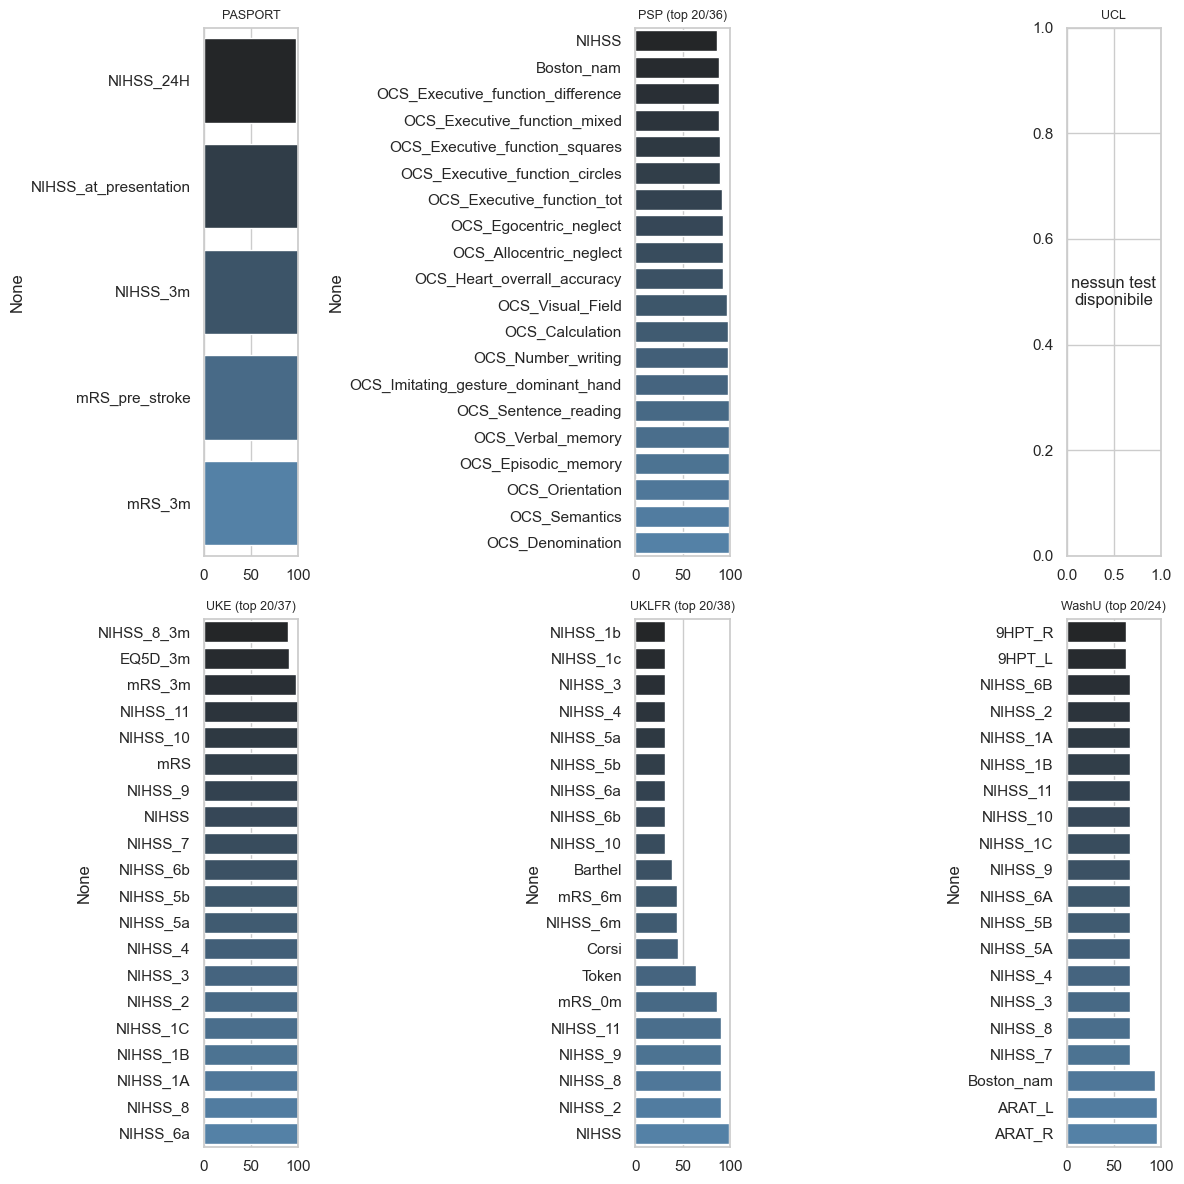

In [97]:
NON_CLINICAL_COLUMNS = {
    "participant_id", "original_id", "participant_id_dmp", "center_id", "disease_id", "disease_notes", "dataset",
    "age", "sex", "handedness", "education", "lesion_side", "lesion_type",
    "clinical_date", "behavioral_date", "behavioural_date", "acq_time", "acquisition_time", "diagnosis_date",
    "time_follow_up_(days)", "lesion_volume_ml", "<gene nomenclature>", "gene_nomvenclature", "codetrt",
    "Creatinine", "Hb", "Platelet_Count", "RBC_Count", "Serum_Glucose", "WBC_Count", "Hct", "INR", "aPTT",
    "Platelet_aggreg_inhib", "Anticoagulants", "Heparine", "LMWH", "Antihypertensives", "Statines", "Antidiabetics",
    "Arterial_hypertension", "Atrial_fibrillation", "TIA", "Ischemic_stroke", "Intracranial_haemorrhage",
    "Hypercholesterolemia", "Diabetes_mellitus_type_II", "Coagulation_disorder", "Gastro_intestinal_bleeding",
}

clinical_cols_by_dataset = {}
for name, df in datasets_tsv.items():
    clinical_cols_by_dataset[name] = [
        c for c in df.columns
        if c not in NON_CLINICAL_COLUMNS and pd.to_numeric(df[c], errors="coerce").notna().any()
    ]

fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(4, 6))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    cols = clinical_cols_by_dataset[name]
    if not cols:
        ax.text(0.5, 0.5, "nessun test\ndisponibile", ha="center", va="center")
        ax.set_title(name, fontsize=9)
        continue

    coverage = pd.Series({c: pd.to_numeric(df[c], errors="coerce").notna().mean() * 100 for c in cols}).sort_values()
    shown = coverage.tail(20)
    sns.barplot(x=shown.values, y=shown.index, hue=shown.index, legend=False, palette="dark:steelblue", ax=ax)
    ax.set_xlim(0, 100)
    ax.set_title(name if len(coverage) <= 20 else f"{name} (top 20/{len(coverage)})", fontsize=9)

plt.tight_layout()
plt.show();


### Gravità Clinica (NIHSS)

NIHSS alla baseline (colonna `NIHSS`), come in produzione (`src/features/clinical.py::join_nihss`): nessun proxy da un'altra colonna, per non fare un'equivalenza clinica che non ci compete. PASPORT e UCL non hanno `NIHSS` e restano `NaN`. I controlli sani vengono esclusi.

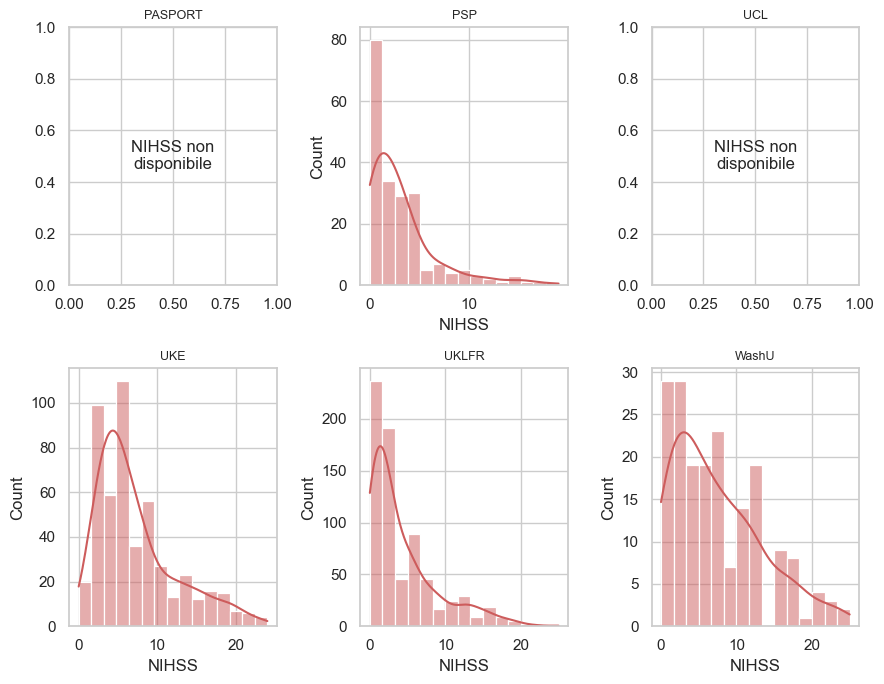

In [98]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(3, 3.5))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    if "NIHSS" not in df.columns:
        ax.text(0.5, 0.5, "NIHSS non\ndisponibile", ha="center", va="center")
    else:
        df_st = df[df["disease_id"] == "ST"] if df["disease_id"].nunique() > 1 else df
        values = pd.to_numeric(df_st["NIHSS"], errors="coerce").dropna()
        if values.empty:
            ax.text(0.5, 0.5, "tutti mancanti", ha="center", va="center")
        else:
            sns.histplot(values, bins=15, color="indianred", kde=True, ax=ax)

    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show();


### Matrice di Correlazione

Correlazione di Pearson tra età, istruzione e le colonne cliniche rilevate sopra — per dataset, quindi ogni matrice ha le sue variabili.

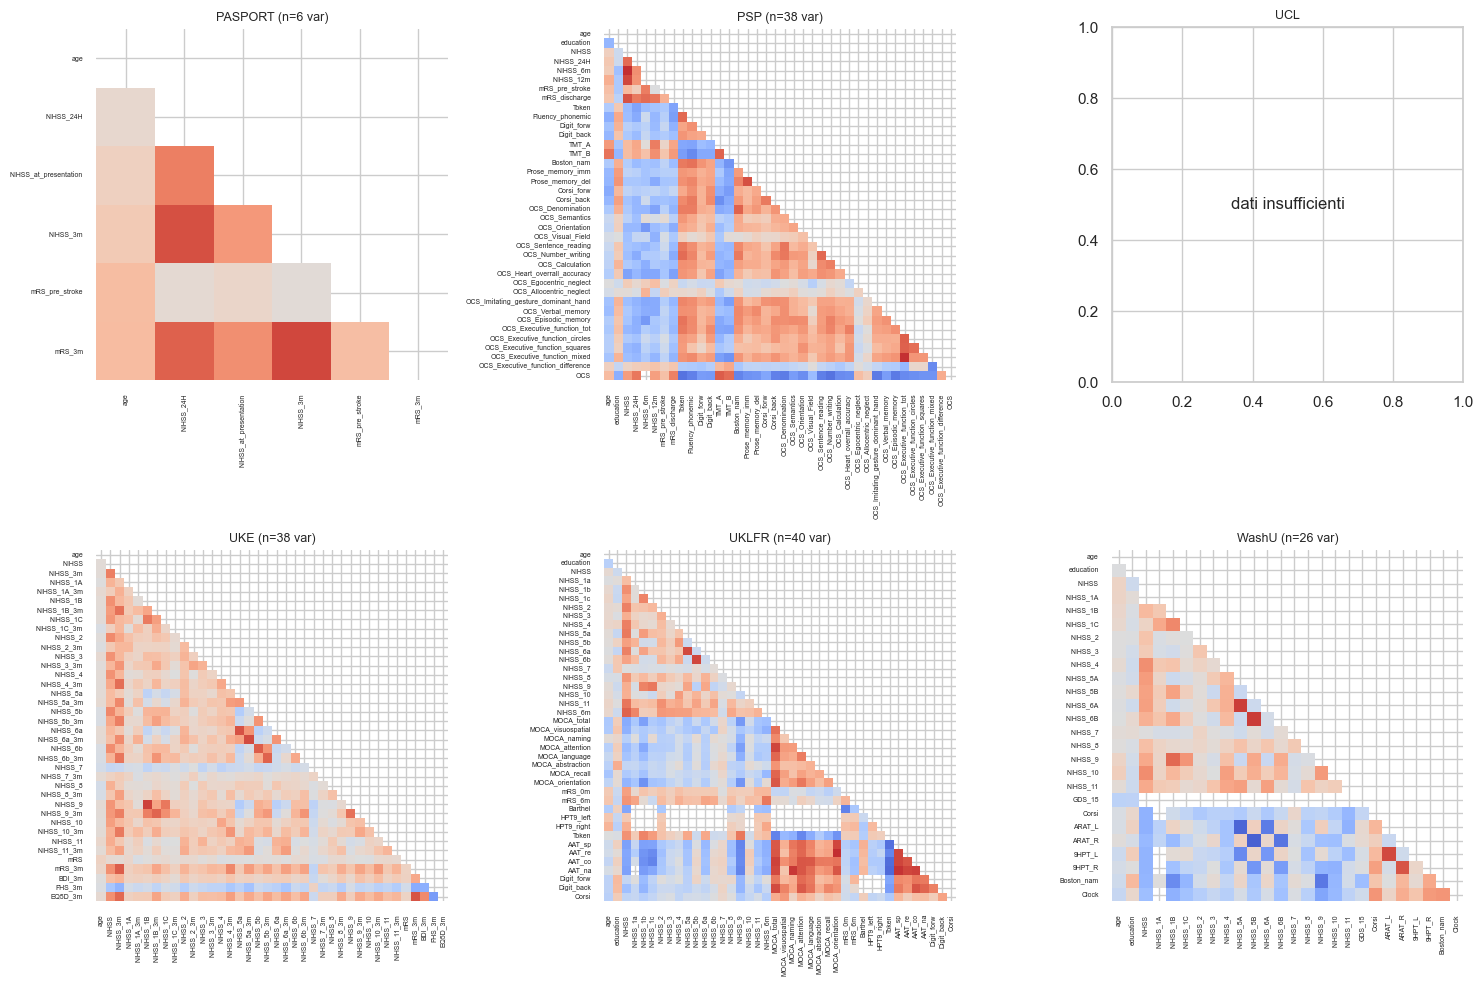

In [99]:
fig, axes = dataset_grid(len(datasets_tsv), n_cols=3, subplot_size=(5, 5))

for ax, (name, df) in zip(axes, datasets_tsv.items()):
    corr_cols = [c for c in ["age", "education"] if c in df.columns] + clinical_cols_by_dataset[name]
    numeric_df = df[corr_cols].apply(pd.to_numeric, errors="coerce") if corr_cols else pd.DataFrame()
    numeric_df = numeric_df.loc[:, numeric_df.notna().sum() > 1]

    if numeric_df.shape[1] < 2:
        ax.text(0.5, 0.5, "dati insufficienti", ha="center", va="center")
        ax.set_title(name, fontsize=9)
        continue

    corr = numeric_df.corr(method="pearson")
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True,
                cbar=False, ax=ax, xticklabels=True, yticklabels=True)
    ax.set_title(f"{name} (n={numeric_df.shape[1]} var)", fontsize=9)
    ax.tick_params(axis="both", labelsize=5)

plt.tight_layout()
plt.show();
